In [1]:
import os

os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION_VERSION"] = "2"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import sys
import subprocess


def _ensure_protobuf_compatible():
    """
    Bug fix: Some Kaggle images ship protobuf>=5 which can crash TF/Keras at import/runtime.
    Keep minimal: only downgrade if major>=5.
    """
    try:
        from importlib.metadata import version as _pkg_version

        v = _pkg_version("protobuf")
        major = int(v.split(".")[0])
        if major >= 5:
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", "-q", "protobuf<5"]
            )
            for m in list(sys.modules.keys()):
                if m.startswith("google.protobuf"):
                    del sys.modules[m]
    except Exception as e:
        print("Warning: protobuf compatibility step encountered:", repr(e))


_ensure_protobuf_compatible()

import gc
import time
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.autonotebook import tqdm

import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

from keras import Sequential
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam, SGD
from keras.layers import Dense, Dropout, Lambda, Input, GlobalAveragePooling2D
from keras.utils import to_categorical
from keras.preprocessing.image import load_img
from tensorflow.keras.models import Model

print("Python:", os.sys.version.split()[0])
print("TensorFlow:", tf.__version__)



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 8.0 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 4.25.8 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2025.10.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
/tmp/ipykernel_11/2572378175.py:43: TqdmExperim

Python: 3.11.13
TensorFlow: 2.18.0


In [2]:
labels = pd.read_csv("/kaggle/input/dog-breed-identification/labels.csv")
labels.head()



,id,breed
0,8406d837b2d7fac1c3cd621abb4c4f9e,west_highland_white_terrier
1,e270622b5ffec8294d7e7628c4ff6c1e,brittany_spaniel
2,41295c36303043fc587e791b14ef2272,basset
3,b63b0200ddbb97df81972b26574959ab,boxer
4,2c64e362c9aa29450082291264dcba29,flat-coated_retriever


In [3]:
classes = sorted(list(set(labels["breed"])))
n_classes = len(classes)
print("Total unique breed {}".format(n_classes))

class_to_num = dict(zip(classes, range(n_classes)))



Total unique breed 120


In [4]:
input_shape = (331, 331, 3)


def images_to_array(directory, label_dataframe, target_size=input_shape):
    image_labels = label_dataframe["breed"].values
    images = np.zeros(
        [len(label_dataframe), target_size[0], target_size[1], target_size[2]],
        dtype=np.uint8,
    )
    y_idx = np.zeros([len(label_dataframe)], dtype=np.int32)

    for ix, image_name in enumerate(tqdm(label_dataframe["id"].values)):
        img_dir = os.path.join(directory, image_name + ".jpg")
        img = load_img(img_dir, target_size=target_size)
        images[ix] = np.asarray(img, dtype=np.uint8)
        del img

        dog_breed = image_labels[ix]
        y_idx[ix] = class_to_num[dog_breed]

    y = to_categorical(y_idx, num_classes=n_classes).astype(np.float32, copy=False)
    return images, y




In [5]:
TRAIN_DIR_CANDIDATES = [
    "/kaggle/input/dog-breed-identification/train",
    "/kaggle/input/dog-breed-identification/dog-breed-identification/train",
]
TRAIN_DIR = next((p for p in TRAIN_DIR_CANDIDATES if os.path.isdir(p)), None)
if TRAIN_DIR is None:
    raise FileNotFoundError(
        f"Could not find train dir in candidates: {TRAIN_DIR_CANDIDATES}"
    )
print("Using TRAIN_DIR:", TRAIN_DIR)

t = time.time()
X, y = images_to_array(TRAIN_DIR, labels[:])
print("runtime in seconds: {}".format(time.time() - t))
print("X:", X.shape, X.dtype, "y:", y.shape, y.dtype)



Using TRAIN_DIR: /kaggle/input/dog-breed-identification/train


  0%|          | 0/9199 [00:00<?, ?it/s]

runtime in seconds: 11.074656248092651
X: (9199, 331, 331, 3) uint8 y: (9199, 120) float32


In [6]:
lrr = ReduceLROnPlateau(
    monitor="val_accuracy", factor=0.01, patience=3, min_lr=1e-5, verbose=1
)
EarlyStop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)



In [7]:
batch_size = 128
epochs = 100
learn_rate = 0.001

sgd = SGD(learning_rate=learn_rate, momentum=0.9, nesterov=False)

adam = Adam(
    learning_rate=learn_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7, amsgrad=False
)



I0000 00:00:1768459234.014034      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 39799 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:c5:00.0, compute capability: 8.6


In [8]:
img_size = (331, 331, 3)


def get_features(model_name, model_preprocessor, input_size, data):
    input_layer = Input(shape=input_size)
    preprocessed = Lambda(model_preprocessor)(input_layer)

    base_model = model_name(
        weights="imagenet", include_top=False, input_shape=input_size
    )
    base_model.trainable = False

    x = base_model(preprocessed, training=False)
    avg = GlobalAveragePooling2D()(x)
    feature_extractor = Model(inputs=input_layer, outputs=avg)

    data = np.asarray(data)
    if data.dtype == object:
        raise ValueError("Input images array has dtype=object; expected numeric uint8.")

    feature_maps = feature_extractor.predict(data, verbose=1, batch_size=64)
    if feature_maps is None:
        raise ValueError(
            "Feature extractor returned None. Check model graph construction."
        )

    feature_maps = np.asarray(feature_maps)
    if feature_maps.dtype == object:
        raise ValueError(
            f"Feature maps dtype=object; got invalid outputs. Shape={feature_maps.shape}"
        )
    feature_maps = np.ascontiguousarray(feature_maps.astype(np.float32, copy=False))

    if feature_maps.ndim != 2:
        raise ValueError(
            f"Expected 2D feature matrix [N,F], got shape={feature_maps.shape}"
        )

    if np.any(~np.isfinite(feature_maps)):
        raise ValueError("Non-finite values found in extracted features.")

    print("Feature maps shape: ", feature_maps.shape, feature_maps.dtype)
    return feature_maps




In [9]:
from keras.applications.inception_v3 import InceptionV3, preprocess_input

inception_preprocessor = preprocess_input

inception_features = get_features(InceptionV3, inception_preprocessor, img_size, X)
print("Inception feature maps shape", inception_features.shape)



87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


I0000 00:00:1768459244.062298      67 service.cc:148] XLA service 0x7f1e38156c60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768459244.062323      67 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
I0000 00:00:1768459244.624479      67 cuda_dnn.cc:529] Loaded cuDNN version 90300


  4/144 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step

I0000 00:00:1768459251.361015      67 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


144/144 ━━━━━━━━━━━━━━━━━━━━ 24s 103ms/step
Feature maps shape:  (9199, 2048) float32
Inception feature maps shape (9199, 2048)


In [10]:
del X
gc.collect()



175187

In [11]:
y = np.asarray(y, dtype=np.float32)
inception_features = np.asarray(inception_features, dtype=np.float32)

y = np.ascontiguousarray(y).astype(np.float32, copy=True)
inception_features = np.ascontiguousarray(inception_features).astype(
    np.float32, copy=True
)

if y.dtype == object or inception_features.dtype == object:
    raise ValueError("Found object dtype in training arrays.")

if np.any(pd.isna(inception_features.reshape(-1))):
    raise ValueError("Found NaN in features.")
if np.any(pd.isna(y.reshape(-1))):
    raise ValueError("Found NaN in labels.")

assert inception_features.ndim == 2, "Expected [N, F] features"
assert y.ndim == 2 and y.shape[1] == n_classes, f"Expected y as [N,{n_classes}]"
assert np.isfinite(inception_features).all(), "Found NaN/Inf in features"
assert np.isfinite(y).all(), "Found NaN/Inf in labels"
assert y.shape[0] == inception_features.shape[0], "Mismatch between X features and y"
assert inception_features.dtype == np.float32, "Features must be float32"
assert y.dtype == np.float32, "Labels must be float32"

# Bug fix: In TF/Keras 2.18+, optimizer configs can legitimately contain None for optional fields
# (e.g., weight_decay, clipnorm). The previous guard incorrectly raised and prevented training.
model = Sequential()
model.add(Dropout(0.7, input_shape=(inception_features.shape[1],)))
model.add(Dense(n_classes, activation="softmax"))

model.compile(optimizer=adam, loss="categorical_crossentropy", metrics=["accuracy"])

history = model.fit(
    inception_features,
    y,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    shuffle=True,
    callbacks=[lrr, EarlyStop],
    verbose=1,
)



Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/regularization/dropout.py:42: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.1766 - loss: 4.1391 - val_accuracy: 0.8424 - val_loss: 1.4357 - learning_rate: 0.0010
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8117 - loss: 1.2027 - val_accuracy: 0.8793 - val_loss: 0.6250 - learning_rate: 0.0010
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8794 - loss: 0.6067 - val_accuracy: 0.8870 - val_loss: 0.4617 - learning_rate: 0.0010
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8957 - loss: 0.4444 - val_accuracy: 0.8902 - val_loss: 0.4033 - learning_rate: 0.0010
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9119 - loss: 0.3633 - val_accuracy: 0.8913 - val_loss: 0.3710 - learning_rate: 0.0010
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9116 - loss: 0.3170 - val_accuracy: 0.8995 - val_loss: 0.3472 - learning_rate: 0.0010
Epoch 7/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9248 - loss: 0.2842 - val_accuracy: 0.90

In [12]:
model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │       245,880 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 737,642 (2.81 MB)

 Trainable params: 245,880 (960.47 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 491,762 (1.88 MB)

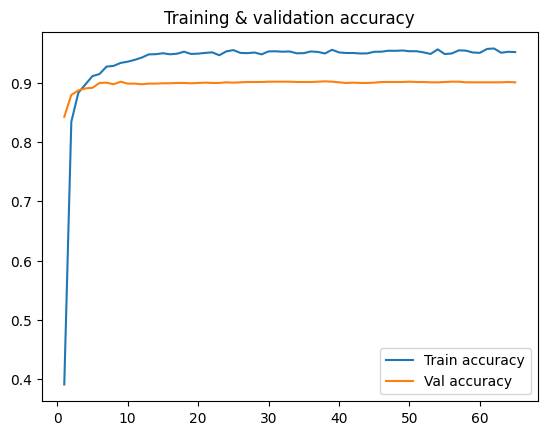

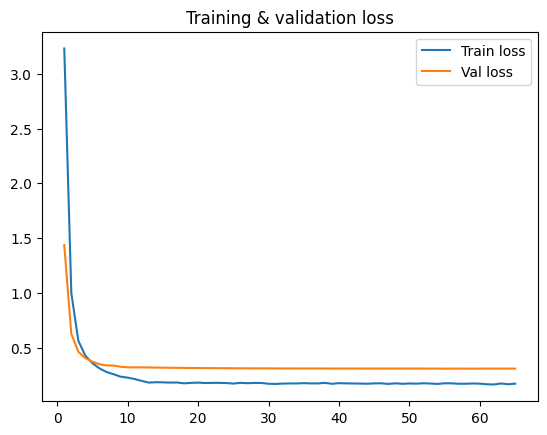

In [13]:
if "history" in globals() and hasattr(history, "history"):
    acc = history.history.get("accuracy", [])
    val_acc = history.history.get("val_accuracy", [])
    loss = history.history.get("loss", [])
    val_loss = history.history.get("val_loss", [])
    epochs_range = range(1, len(acc) + 1)

    plt.plot(epochs_range, acc, label="Train accuracy")
    plt.plot(epochs_range, val_acc, label="Val accuracy")
    plt.title("Training & validation accuracy")
    plt.legend()

    plt.figure()
    plt.plot(epochs_range, loss, label="Train loss")
    plt.plot(epochs_range, val_loss, label="Val loss")
    plt.title("Training & validation loss")
    plt.legend()
    plt.show()
else:
    print("Skipping plots because history is not available.")



In [14]:
del inception_features
gc.collect()




7798

In [15]:
def images_to_array_test(test_path, img_size=(331, 331, 3)):
    fnames = sorted([f for f in os.listdir(test_path) if f.lower().endswith(".jpg")])
    test_filenames = [os.path.join(test_path, f) for f in fnames]

    data_size = len(test_filenames)
    images = np.zeros([data_size, img_size[0], img_size[1], 3], dtype=np.uint8)

    for ix, img_dir in enumerate(tqdm(test_filenames)):
        img = load_img(img_dir, target_size=img_size)
        images[ix] = np.asarray(img, dtype=np.uint8)
        del img

    print("Output Data Size: ", images.shape)
    return images, fnames


TEST_DIR_CANDIDATES = [
    "/kaggle/input/dog-breed-identification/test",
    "/kaggle/input/dog-breed-identification/dog-breed-identification/test",
]
TEST_DIR = next((p for p in TEST_DIR_CANDIDATES if os.path.isdir(p)), None)
if TEST_DIR is None:
    raise FileNotFoundError(
        f"Could not find test dir in candidates: {TEST_DIR_CANDIDATES}"
    )
print("Using TEST_DIR:", TEST_DIR)

test_data, test_fnames = images_to_array_test(TEST_DIR, img_size)




Using TEST_DIR: /kaggle/input/dog-breed-identification/test


  0%|          | 0/1023 [00:00<?, ?it/s]

Output Data Size:  (1023, 331, 331, 3)


In [16]:
def extact_features(data):
    inception_features_local = get_features(
        InceptionV3, inception_preprocessor, img_size, data
    )
    print("Inception feature maps shape", inception_features_local.shape)
    return inception_features_local


test_features = extact_features(test_data)



16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 645ms/step
Feature maps shape:  (1023, 2048) float32
Inception feature maps shape (1023, 2048)


In [17]:
del test_data
gc.collect()



175186

In [18]:
# Safety: fail clearly if training didn't create a model (prevents confusing NameError)
if "model" not in globals():
    raise RuntimeError("Model is not defined; training likely failed earlier.")

pred = model.predict(
    np.asarray(test_features, dtype=np.float32), verbose=1, batch_size=64
)
pred = np.asarray(pred, dtype=np.float32)
print("pred:", pred.shape, pred.dtype)



16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
pred: (1023, 120) float32


In [19]:
sample_sub = pd.read_csv("/kaggle/input/dog-breed-identification/sample_submission.csv")
breed_cols = [c for c in sample_sub.columns if c != "id"]

test_ids = [os.path.splitext(f)[0] for f in test_fnames]

preds_df = pd.DataFrame(pred, columns=classes)
preds_df.insert(0, "id", test_ids)

# Align to sample submission columns/order
preds_df = preds_df.reindex(columns=["id"] + breed_cols)

missing = [c for c in breed_cols if c not in preds_df.columns]
if missing:
    for c in missing:
        preds_df[c] = 1e-12
    preds_df = preds_df.reindex(columns=["id"] + breed_cols)

# Normalize for numerical stability in log-loss (score-neutral/correctness fix)
probs = preds_df[breed_cols].to_numpy(dtype=np.float64)
probs = np.clip(probs, 1e-12, 1.0)
probs = probs / probs.sum(axis=1, keepdims=True)
preds_df[breed_cols] = probs.astype(np.float32)

preds_df.to_csv("submission.csv", index=False)
print("Wrote submission.csv with shape:", preds_df.shape)
print(preds_df.head())

Wrote submission.csv with shape: (1023, 121)
                                 id  affenpinscher  afghan_hound  \
0  0042188c895a2f14ef64a918ed9c7b64       0.000064  1.178577e-04   
1  007ff9a78eba2aebb558afea3a51c469       0.000003  1.450561e-07   
2  00cc68a50b2d016a6b29af628ea4e04b       0.000013  5.577241e-06   
3  00fda6ecca54efbac26e907be4b0b78b       0.000216  4.153505e-05   
4  010e87fdf252645a827e37470e65e842       0.000111  6.739313e-06   

   african_hunting_dog  airedale  american_staffordshire_terrier  appenzeller  \
0         7.721696e-05  0.000061                    1.659644e-05     0.000071   
1         5.531722e-07  0.003763                    1.861820e-06     0.000003   
2         6.197488e-06  0.000003                    1.644295e-05     0.000050   
3         2.530270e-05  0.000014                    7.767388e-07     0.000003   
4         6.432678e-06  0.000013                    1.306772e-06     0.000012   

   australian_terrier   basenji        basset  ...  toy_poo